This notebook produces simulations for assessing how power (TPR) changes as a function of CRE_oi (oi = "of interest") strength, for the hypothesis "CRE_oi is significantly different from minP".

In a simulation
- The number of cells changes the power (naturally: more samples or less samples)
- The number of unique CREs also hanges the power: for a fixed MOI, a library with more elements will have less representation of each element.

This means that we can't just manipulate these freely.

Realistically, CRE_oi vs minP will be done within one cell-type. I'll choose "reference" (PSCs)

With this in mind, we'll

1. Draw n CREs from a log uniform distribution spanning from 0 to the max CRE strength, for n=number of CREs detected in PSCs
2. Add a reference CRE
3. simulate m cells, where m is the number of PSCs in the original dataset, across 5 replicates
4. Then for each replicate we calculate mwu
5. Repeat 1-4 5x times...

Then we summarize performance
1. load all the results DF
2. drop everything except cre_oi and T/F call
3. bin / plot

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
from pathlib import Path
import numpy as np
import uuid
import pandas as pd

2026-02-03 15:28:33.097404: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-03 15:28:33.161520: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [2]:
data_root=Path("/nfs/roberts/project/pi_skr2/shared/tabula_data")

In [8]:
local=False
if local:
    cluster=LocalCluster(memory_limit='48G')
    client=Client(cluster)
else:
    cluster=SLURMCluster(
        cores=3,#cores per slurm job
        memory="16G",#memory per slurm job
        processes=1,#dask workers per slurm job,
        job_extra_directives=["-p day", 
            f"--job-name=simclust_worker",
            f"--time=6:00:00",
            f"--output=worker_%j.out"]
    )
    #cluster.scale(jobs=20)
    cluster.scale(jobs=5)
    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )

In [9]:
#copy the bounds
bound=scm.SHENDURE_BOUNDS.copy()
#we are only simulating one cell type 
bound.cells_per_cell_type=scm.SHENDURE_BOUNDS.cells_per_cell_type.loc[["reference"]]

In [10]:
primordial=scm.ortho.load(client,data_root/"shendure","ortho_primordial_v4")
dat=primordial.training_data.data
n_cres=len(dat[dat["cell_type"]=="reference"]["cre_id"].unique())
del primordial

In [11]:
max=scm.SHENDURE_BOUNDS.max_mpra_umi
min=scm.SHENDURE_BOUNDS.min_mpra_umi
#cells=scm.SHENDURE_BOUNDS.cells_per_cell_type["reference"]
minP=scm.SHENDURE_BOUNDS.reference_activity

In [12]:
def one_library_replicate(root,reps):
    #create ground truth dataframe
    rng = np.random.default_rng()
    cre_gt=rng.uniform(min,max,size=n_cres-1)
    cre_gt=np.append(cre_gt,minP)
    names=[f"synthcre_{i}" for i in range(0,n_cres-1)]+["reference"]

    gt_df=pd.DataFrame({"cre_id":names,"mu":cre_gt})
    gt_df["cell_type"]="reference"

    # simulate libraries
    libraries=[scm.simulate_library(CREs=gt_df["cre_id"],
                 library_model=scm.SHENDURE_BOUNDS.library_model)
                 for i in range(reps)]
    
    #initalize the simulated replicate
    name=uuid.uuid4().hex[:8]
    
    sim=scm.de_novo_simulation(location=root,
                            name=f"sim_{name}",
                            client=client,
                            libraries=libraries,
                            library_mapping="corresponding",
                            flatten_overtransfection=False,
                            n_sims=reps,
                            experiment_bounds=bound,
                            ground_truth=gt_df)
    sim.gamut()
    
    return name, sim

In [13]:
names=[]
sims=[]
for i in range(5):
    name, sim = one_library_replicate(root=data_root/"2026-02-02_dense_shendure_pow",reps=5)
    sims.append(sim)
    names.append(name)


scMPRAforge: INFO: No 'state.parquet' found for 'sim_95bca571'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_4de79cb5'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_c76c7e1c'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_38987692'. Initalizing new object.
scMPRAforge: INFO: No 'state.parquet' found for 'sim_bd8188a9'. Initalizing new object.


In [14]:
for sim in sims:
    sim.save()

In [19]:
example_data=scm.scMPRA_data.from_parquet(sims[0].scmpradatp/"0.scmpra")
example_data

In [20]:
hs_all_ct = scm.make_all_by_celltype_hypotheses(
    counts=example_data,
    reference_cre="reference",
)

In [22]:
for sim in sims:
    sim.add_hypothesis_set("hs_all_ct",hs_all_ct)
    sim.mwu("hs_all_ct")

for sim in sims:
    sim.save()

In [ ]:
sims[0].get_state_field("n_sims")

5

In [34]:
mergy=sims[0]._merge_in_ground_truth(hypothesis_set_name="hs_all_ct",test_type="mwu",index=0)
mergy=mergy[["reject_null","comp_mean"]]
mergy["comp_mean"]=mergy["comp_mean"].astype("float")
mergy

,reject_null,comp_mean
0,True,55.089620
1,True,12.286326
2,True,23.039801
3,True,50.761288
4,True,60.016958
...,...,...
201,True,47.846413
202,True,20.481804
203,True,58.022685
204,True,20.845839


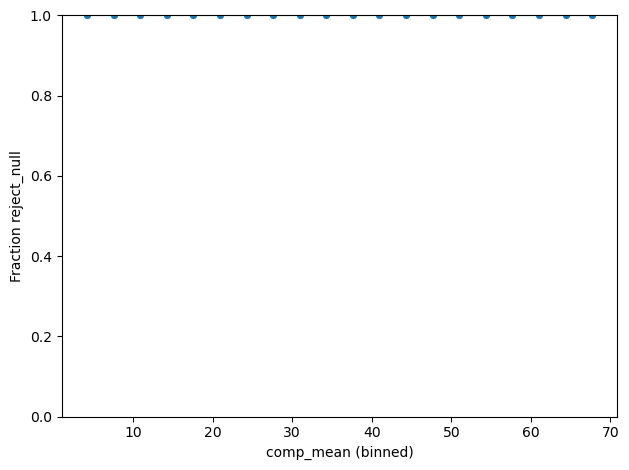

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# choose number of bins
n_bins = 20

# bin comp_mean
df = mergy.copy()
df["comp_bin"] = pd.cut(df["comp_mean"], bins=n_bins)

# aggregate: fraction of True in each bin
binned = (
    df.groupby("comp_bin", observed=True)["reject_null"]
      .mean()
      .reset_index(name="reject_frac")
)

# bin centers for plotting
binned["bin_center"] = binned["comp_bin"].apply(lambda x: x.mid)

# plot
sns.lineplot(
    data=binned,
    x="bin_center",
    y="reject_frac",
    marker="o"
)

plt.xlabel("comp_mean (binned)")
plt.ylabel("Fraction reject_null")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
#time to summarize...
def combine_tests(sims):
    """
    """


In [7]:
client.close()
cluster.close()